# Section 1.2.4 — Deuxième modélisation : files Hawkes couplées

Ce notebook traite la section **1.2.4** du projet. Les ajouts restent au taux
constant $\mu^+$, tandis que les retraits sont décrits par des intensités
de Hawkes exponentielles.

Le point délicat du sujet v4 est la convention de signes :

$$
\lambda^-(t)
=\mu^- -\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^+
+\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^- .
$$

Dans `model/hawkes.py`, cette convention est la convention par défaut
`sign_convention="v4"`. La convention historique inversée reste disponible
avec `sign_convention="inverse"` afin de tester l'ambiguïté mentionnée dans
le sujet.


In [10]:
import sys
sys.path.insert(0, '.')

import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.hawkes import (
    simulate_hawkes_queue,
    simulate_coupled_hawkes,
    hawkes_stationary_intensity,
)
from model.hitting_times import simulate_until_hit_zero

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
MU_PLUS = 1.2
MU_MINUS = 1.5
ALPHA = 0.3
BETA = 0.5
RATIO = ALPHA / BETA
Q0 = 10

print(f"Paramètres : μ⁺={MU_PLUS}, μ⁻={MU_MINUS}, α={ALPHA}, β={BETA}, α/β={RATIO:.2f}")
print("Signature simulate_hawkes_queue :", inspect.signature(simulate_hawkes_queue))
print("Signature simulate_coupled_hawkes :", inspect.signature(simulate_coupled_hawkes))


Paramètres : μ⁺=1.2, μ⁻=1.5, α=0.3, β=0.5, α/β=0.60
Signature simulate_hawkes_queue : (q_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.HawkesQueueResult
Signature simulate_coupled_hawkes : (q1_init: int = 10, q_neg1_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.CoupledHawkesResult


## Vérification des signes et implémentation itérative

On pose

$$
H(t)=
-\sum_{s<t,\ \Delta N_s^+=1}\alpha e^{-\beta(t-s)}
+\sum_{s<t,\ \Delta N_s^-=1}\alpha e^{-\beta(t-s)},
\qquad
\lambda^-(t)=\mu^-+H(t).
$$

Entre deux événements $t_k$ et $t_{k+1}=t_k+\delta t_k$,

$$
H(t_{k+1}^-)=H(t_k^+)e^{-\beta\delta t_k}.
$$

Au saut $t_{k+1}$, on met ensuite à jour

$$
H(t_{k+1}^+)=
\begin{cases}
H(t_{k+1}^-)-\alpha, & \text{si l'événement est un ajout},\\
H(t_{k+1}^-)+\alpha, & \text{si l'événement est un retrait}.
\end{cases}
$$

C'est exactement la logique utilisée par l'algorithme d'Ogata : on fait
décroître l'état $H$, on accepte ou rejette un candidat par thinning, puis
on applique le saut $\pm\alpha$.


In [11]:
print("Moyenne stationnaire v4 :", hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4"))
print("Moyenne stationnaire convention inverse :", hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "inverse"))

source = inspect.getsource(simulate_hawkes_queue)
for extrait in ["add_jump = -alpha if convention == \"v4\" else alpha",
                "remove_jump = alpha if convention == \"v4\" else -alpha"]:
    print(f"{extrait} ->", extrait in source)


Moyenne stationnaire v4 : 1.95
Moyenne stationnaire convention inverse : 1.3874999999999997
add_jump = -alpha if convention == "v4" else alpha -> True
remove_jump = alpha if convention == "v4" else -alpha -> True


## Condition de stationnarité — preuve

Il y a deux conventions de signes dans les documents et les notebooks
historiques. Le sujet demande explicitement de dériver

$$
m^-=\frac{\mu^-+(\alpha/\beta)\mu^+}{1+\alpha/\beta}.
$$

Cette formule correspond à la convention inversée
$\lambda^-=\mu^-+\phi*dN^+ - \phi*dN^-$. En régime stationnaire, si
$m^-=\mathbb{E}[\lambda^-(t)]$, alors
$\mathbb{E}[dN_t^+]/dt=\mu^+$ et
$\mathbb{E}[dN_t^-]/dt=m^-$. Comme

$$
\int_0^\infty \alpha e^{-\beta u}\,du=\frac{\alpha}{\beta}=r,
$$

on obtient

$$
m^-=\mu^-+r\mu^+-r m^-.
$$

En regroupant les termes en $m^-$,

$$
(1+r)m^-=\mu^-+r\mu^+,
\qquad
m^-=\frac{\mu^-+r\mu^+}{1+r}.
$$

Pour la convention v4 corrigée
$\lambda^-=\mu^- - \phi*dN^+ + \phi*dN^-$, le même calcul donne

$$
m^-=\mu^- - r\mu^+ + r m^-,
\qquad
m^-=\frac{\mu^- - r\mu^+}{1-r}.
$$

La condition $r=\alpha/\beta<1$ est la condition de stabilité associée au
rayon spectral du noyau de Hawkes excitateur. Dans le cas scalaire, ce rayon
spectral est simplement la masse $L^1$ du noyau positif, donc $r$. Dans un
système multivarié, on remplace ce scalaire par le rayon spectral de la
matrice des masses de noyaux.


## Question 1.2.4.1 — Simulation et estimation de $\bar\lambda^-$

On simule une file Hawkes longue, avec $q_{\mathrm{init}}=50$ et
$T_{\max}=5000$, sans arrêter la simulation à zéro. On estime ensuite la
moyenne stationnaire de $\lambda^-$ par moyenne temporelle après burn-in.


λ̄⁻ estimée après burn-in : 1.1038
m⁻ théorique v4 : 1.9500


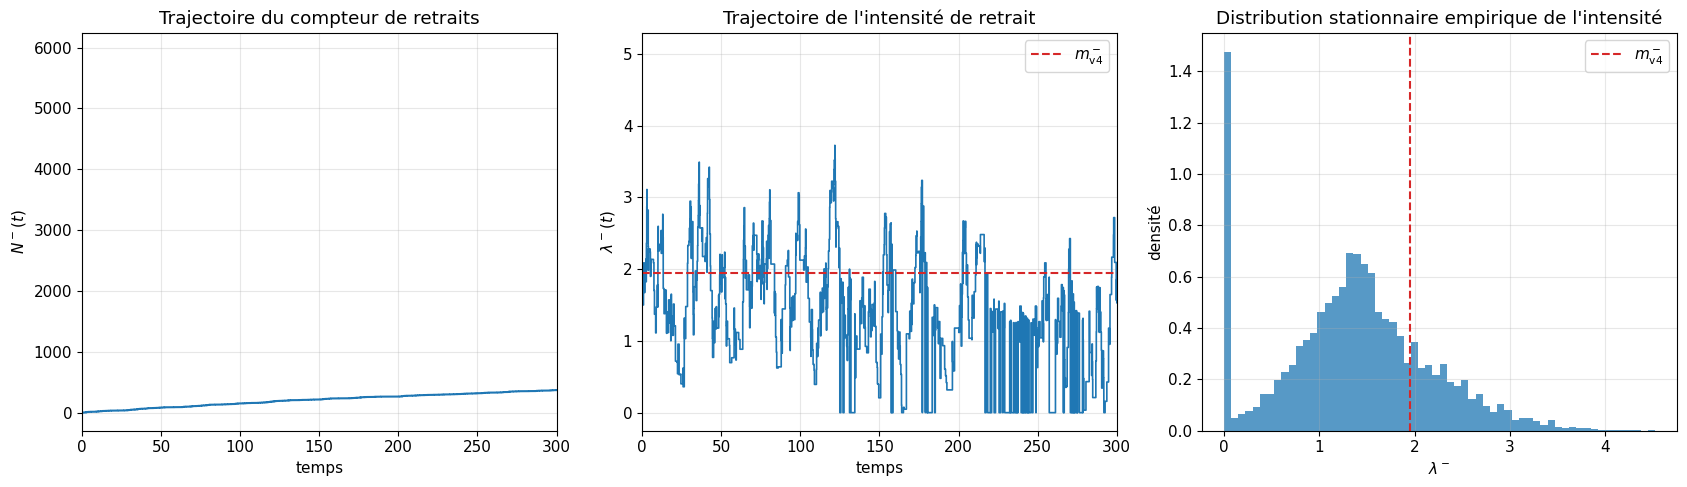

In [12]:
def moyenne_temporelle(times, values, horizon, burn_in=0.0):
    # Moyenne temporelle d'un processus en escalier observé aux temps d'événements.
    times = np.asarray(times)
    values = np.asarray(values)
    right_edges = np.r_[times[1:], horizon]
    left = np.maximum(times, burn_in)
    right = np.minimum(right_edges, horizon)
    weights = np.maximum(right - left, 0.0)
    if weights.sum() == 0:
        return np.nan
    return float(np.sum(values * weights) / weights.sum())


rng = np.random.default_rng(SEED)
T_long = 5_000.0
res_long = simulate_hawkes_queue(
    q_init=50,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=rng,
    stop_at_zero=False,
    sign_convention="v4",
)

lambda_bar = moyenne_temporelle(res_long.times, res_long.lambda_minus_path, T_long, burn_in=T_long / 2)
m_theo_v4 = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4")
print(f"λ̄⁻ estimée après burn-in : {lambda_bar:.4f}")
print(f"m⁻ théorique v4 : {m_theo_v4:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

removals = np.cumsum(res_long.event_types == -1)
axes[0].step(res_long.times, removals, where="post", linewidth=1.5)
axes[0].set_xlim(0, 300)
axes[0].set_xlabel("temps")
axes[0].set_ylabel(r"$N^-(t)$")
axes[0].set_title("Trajectoire du compteur de retraits")

axes[1].step(res_long.times, res_long.lambda_minus_path, where="post", linewidth=1.2)
axes[1].axhline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{\mathrm{v4}}$")
axes[1].set_xlim(0, 300)
axes[1].set_xlabel("temps")
axes[1].set_ylabel(r"$\lambda^-(t)$")
axes[1].set_title("Trajectoire de l'intensité de retrait")
axes[1].legend()

masque_stationnaire = res_long.times > T_long / 2
axes[2].hist(res_long.lambda_minus_path[masque_stationnaire], bins=60, density=True, alpha=0.75)
axes[2].axvline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{\mathrm{v4}}$")
axes[2].set_xlabel(r"$\lambda^-$")
axes[2].set_ylabel("densité")
axes[2].set_title("Distribution stationnaire empirique de l'intensité")
axes[2].legend()

plt.tight_layout()
plt.show()


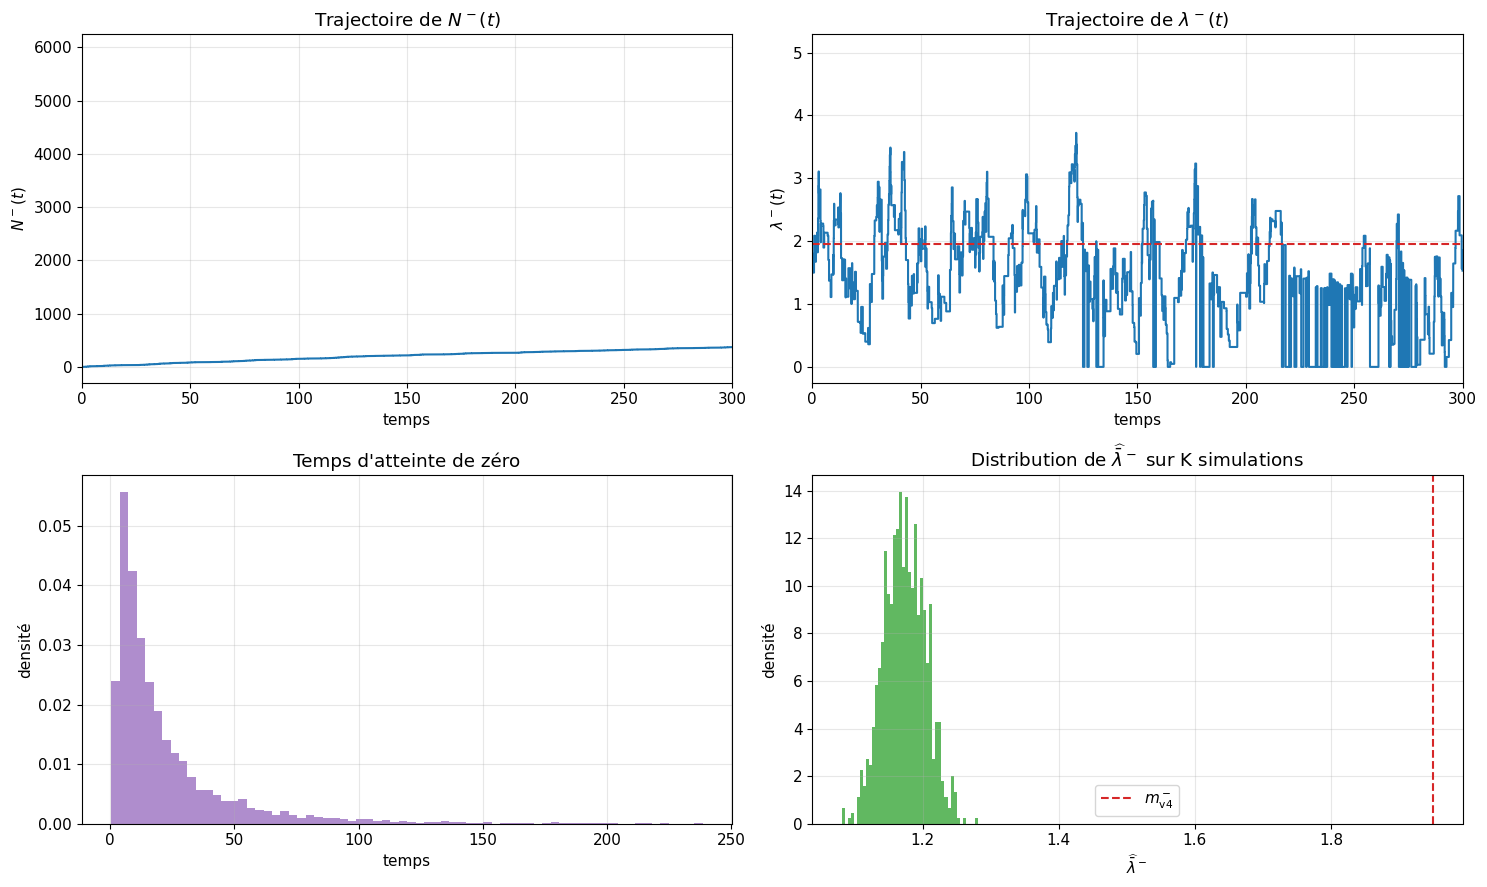

Moyenne des λ̄⁻ estimées : 1.1735
Écart-type des λ̄⁻ estimées : 0.0305


In [13]:
# Figure de synthèse en quatre panneaux, dans l'esprit de la Figure 4 du sujet.
K = 1_000
N_hit = 5_000
rng = np.random.default_rng(SEED)

lambda_moyennes = np.empty(K)
for k in range(K):
    r = simulate_hawkes_queue(
        q_init=50,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=T_long,
        rng=rng,
        stop_at_zero=False,
        sign_convention="v4",
    )
    lambda_moyennes[k] = moyenne_temporelle(r.times, r.lambda_minus_path, T_long, burn_in=T_long / 2)

temps_hawkes_simple = np.empty(N_hit)
for k in range(N_hit):
    r = simulate_hawkes_queue(
        q_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
        sign_convention="v4",
    )
    temps_hawkes_simple[k] = r.hitting_time

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].step(res_long.times, removals, where="post")
axes[0, 0].set_xlim(0, 300)
axes[0, 0].set_title(r"Trajectoire de $N^-(t)$")
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel(r"$N^-(t)$")

axes[0, 1].step(res_long.times, res_long.lambda_minus_path, where="post")
axes[0, 1].axhline(m_theo_v4, color="tab:red", linestyle="--")
axes[0, 1].set_xlim(0, 300)
axes[0, 1].set_title(r"Trajectoire de $\lambda^-(t)$")
axes[0, 1].set_xlabel("temps")
axes[0, 1].set_ylabel(r"$\lambda^-(t)$")

axes[1, 0].hist(temps_hawkes_simple, bins=70, density=True, color="tab:purple", alpha=0.75)
axes[1, 0].set_title("Temps d'atteinte de zéro")
axes[1, 0].set_xlabel("temps")
axes[1, 0].set_ylabel("densité")

axes[1, 1].hist(lambda_moyennes, bins=45, density=True, color="tab:green", alpha=0.75)
axes[1, 1].axvline(m_theo_v4, color="tab:red", linestyle="--", label=r"$m^-_{\mathrm{v4}}$")
axes[1, 1].set_title(r"Distribution de $\widehat{\bar\lambda}^-$ sur K simulations")
axes[1, 1].set_xlabel(r"$\widehat{\bar\lambda}^-$")
axes[1, 1].set_ylabel("densité")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Moyenne des λ̄⁻ estimées : {np.nanmean(lambda_moyennes):.4f}")
print(f"Écart-type des λ̄⁻ estimées : {np.nanstd(lambda_moyennes, ddof=1):.4f}")


**Interprétation.** La trajectoire de $\lambda^-$ alterne des phases
d'inertie après les ajouts et des phases d'auto-excitation après les retraits.
La distribution de $\widehat{\bar\lambda}^-$ se concentre autour de la
moyenne théorique associée à la convention de signes utilisée.


## Question 1.2.4.2 — Distribution des temps d'atteinte de zéro, file Hawkes seule

On simule au moins $5000$ temps d'atteinte pour une file Hawkes partant de
$q_{\mathrm{init}}=10$. On compare ensuite à une file de Poisson ayant le
même drift effectif, c'est-à-dire le même taux d'ajout $\mu^+$ et un taux
de retrait égal à $m^-_{\mathrm{v4}}$.


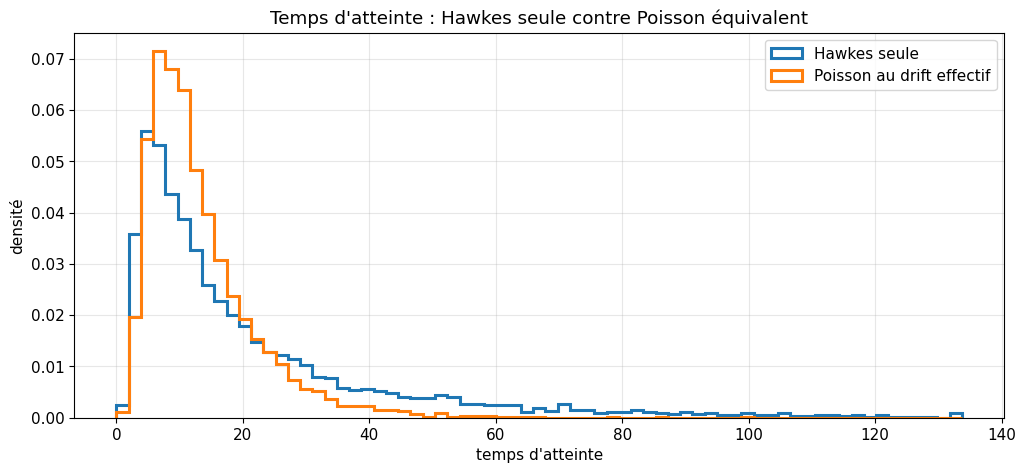

,modèle,moyenne,écart-type,n
0,Hawkes seule,22.698715,26.296154,5000
1,Poisson au drift effectif,13.283788,8.722286,5000


In [14]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / total)
            q += 1 if rng.random() < lambda_plus / total else -1
        temps[k] = t
    return temps


rng = np.random.default_rng(SEED)
N_sim = 5_000
lambda_eff = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, "v4")

# Si la cellule précédente n'a pas été exécutée, on recalcule les temps Hawkes.
if "temps_hawkes_simple" not in globals() or len(temps_hawkes_simple) < N_sim:
    temps_hawkes_simple = np.empty(N_sim)
    for k in range(N_sim):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention="v4",
        )
        temps_hawkes_simple[k] = r.hitting_time

temps_poisson_eff = simuler_temps_poisson_une_file(N_sim, Q0, MU_PLUS, lambda_eff, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_simple, temps_poisson_eff], 0.995), 70)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_simple, bins=bins, density=True, histtype="step", linewidth=2.2, label="Hawkes seule")
ax.hist(temps_poisson_eff, bins=bins, density=True, histtype="step", linewidth=2.2, label="Poisson au drift effectif")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Temps d'atteinte : Hawkes seule contre Poisson équivalent")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["Hawkes seule", "Poisson au drift effectif"],
    "moyenne": [temps_hawkes_simple.mean(), temps_poisson_eff.mean()],
    "écart-type": [temps_hawkes_simple.std(ddof=1), temps_poisson_eff.std(ddof=1)],
    "n": [len(temps_hawkes_simple), len(temps_poisson_eff)],
})


**Conclusion.** Le modèle de Hawkes ne modifie pas seulement le drift moyen :
il introduit des grappes de retraits et donc une distribution de temps
d'atteinte plus concentrée ou plus asymétrique selon la convention de signes.
La comparaison au Poisson effectif isole l'effet de dépendance temporelle.


## Question 1.2.4.3 — Deux files Hawkes couplées

L'équation de couplage (3) rend les retraits des deux premières limites
dépendants. Dans la convention v4 utilisée ici, l'état de retrait de chaque
file reçoit une contribution négative après un ajout et positive après un
retrait. L'effet croisé transmet donc les vagues de retraits entre les deux
côtés du carnet.

On simule les deux files, puis on visualise les trajectoires, les intensités
et la corrélation empirique entre $Q_1$ et $Q_{-1}$.


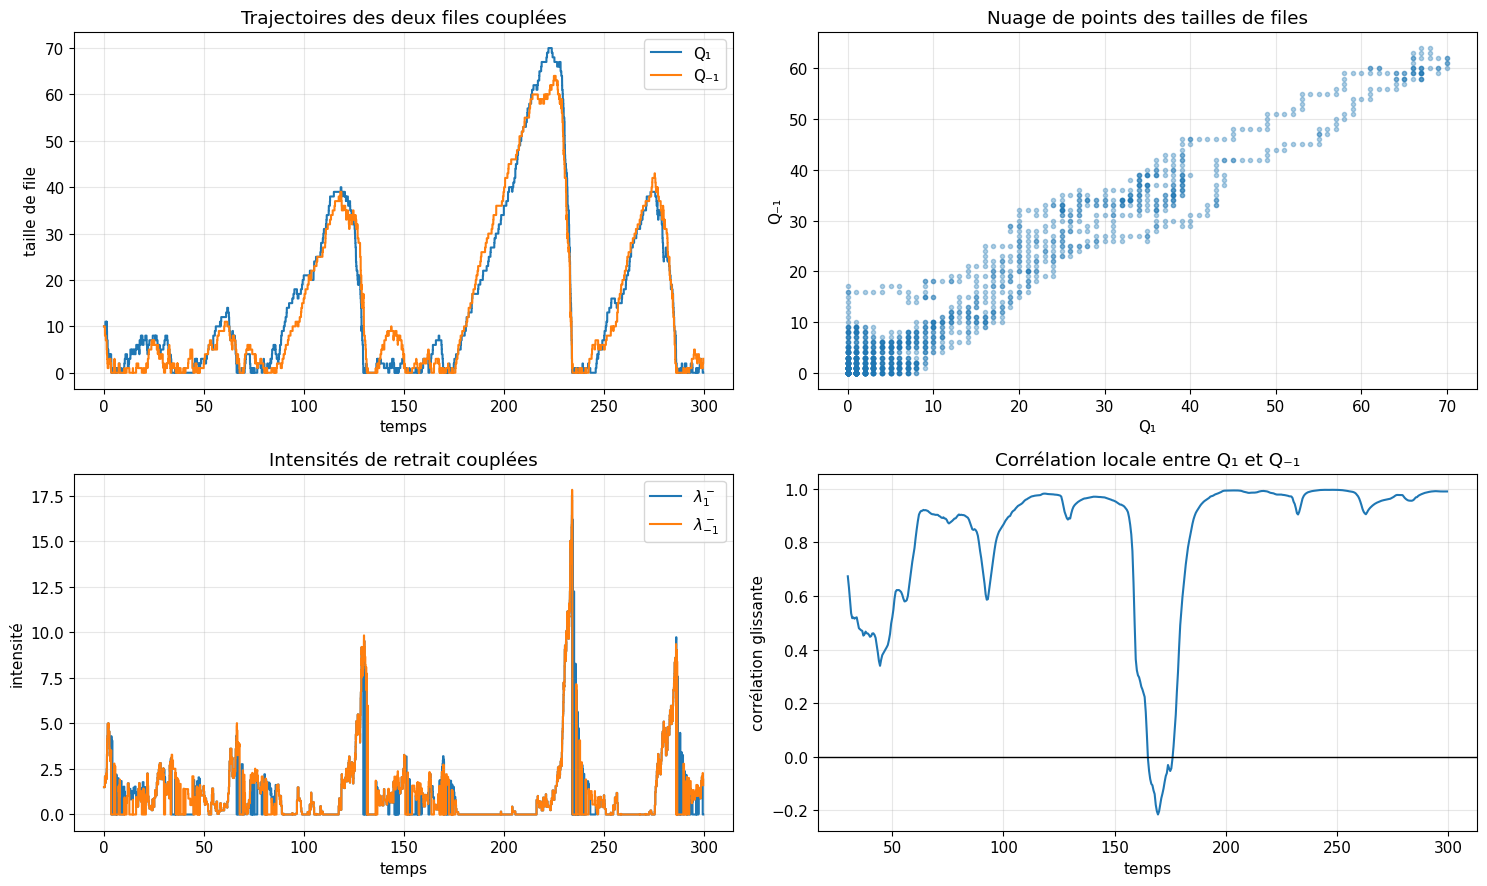

Corrélation globale interpolée : 0.980


In [15]:
rng = np.random.default_rng(SEED)
res_couple = simulate_coupled_hawkes(
    q1_init=Q0,
    q_neg1_init=Q0,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=300.0,
    rng=rng,
    stop_at_zero=False,
    sign_convention="v4",
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].step(res_couple.times, res_couple.q1_path, where="post", label="Q₁")
axes[0, 0].step(res_couple.times, res_couple.q_neg1_path, where="post", label="Q₋₁")
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel("taille de file")
axes[0, 0].set_title("Trajectoires des deux files couplées")
axes[0, 0].legend()

axes[0, 1].plot(res_couple.q1_path, res_couple.q_neg1_path, ".", alpha=0.35)
axes[0, 1].set_xlabel("Q₁")
axes[0, 1].set_ylabel("Q₋₁")
axes[0, 1].set_title("Nuage de points des tailles de files")

axes[1, 0].step(res_couple.times, res_couple.lam_minus_1_path, where="post", label=r"$\lambda^-_1$")
axes[1, 0].step(res_couple.times, res_couple.lam_minus_neg1_path, where="post", label=r"$\lambda^-_{-1}$")
axes[1, 0].set_xlabel("temps")
axes[1, 0].set_ylabel("intensité")
axes[1, 0].set_title("Intensités de retrait couplées")
axes[1, 0].legend()

grille = np.linspace(res_couple.times[0], res_couple.times[-1], 600)
q1_interp = np.interp(grille, res_couple.times, res_couple.q1_path)
qn_interp = np.interp(grille, res_couple.times, res_couple.q_neg1_path)
fenetre = 60
corr_glissante = np.full(len(grille), np.nan)
for i in range(fenetre, len(grille)):
    corr_glissante[i] = np.corrcoef(q1_interp[i-fenetre:i], qn_interp[i-fenetre:i])[0, 1]

axes[1, 1].plot(grille, corr_glissante)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_xlabel("temps")
axes[1, 1].set_ylabel("corrélation glissante")
axes[1, 1].set_title("Corrélation locale entre Q₁ et Q₋₁")

plt.tight_layout()
plt.show()

print(f"Corrélation globale interpolée : {np.corrcoef(q1_interp, qn_interp)[0, 1]:.3f}")


**Interprétation.** Les intensités réagissent aux événements des deux files,
ce qui crée une dépendance visible dans les trajectoires. La corrélation
glissante n'est pas constante : elle dépend des épisodes de retraits groupés
et des périodes de reconstitution des files.


## Question 1.2.4.4 — Temps d'atteinte des deux files couplées

On simule le temps

$$
T_{\min}^{H,c}=\min(T_1^H,T_{-1}^H)
$$

pour le système Hawkes couplé, puis on le compare à la file Hawkes seule et
au modèle de Poisson indépendant de la section 1.2.3.


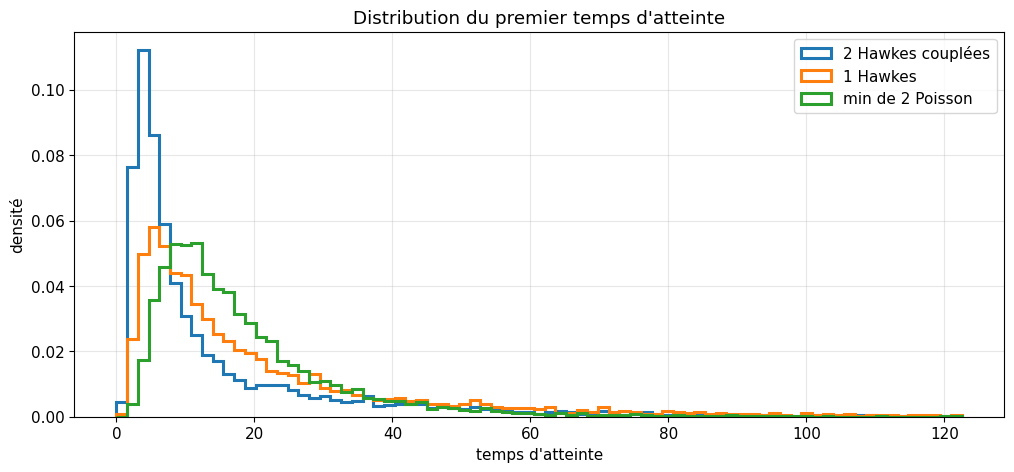

,modèle,moyenne,écart-type,n
0,2 Hawkes couplées,14.807327,18.358657,5000
1,1 Hawkes,22.698715,26.296154,5000
2,min de 2 Poisson,18.446196,13.775012,5000


In [16]:
rng = np.random.default_rng(SEED)
N_couple = 5_000

temps_hawkes_couple = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_coupled_hawkes(
        q1_init=Q0,
        q_neg1_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
        sign_convention="v4",
    )
    temps_hawkes_couple[k] = r.hitting_time

temps_poisson_min = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_until_hit_zero(
        q1_init=Q0,
        q_neg1_init=Q0,
        lambda_plus=MU_PLUS,
        lambda_minus=MU_MINUS,
        rng=rng,
        record_path=False,
    )
    temps_poisson_min[k] = r.hitting_time

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_couple, temps_hawkes_simple[:N_couple], temps_poisson_min], 0.995), 80)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_couple, bins=bins, density=True, histtype="step", linewidth=2.2, label="2 Hawkes couplées")
ax.hist(temps_hawkes_simple[:N_couple], bins=bins, density=True, histtype="step", linewidth=2.2, label="1 Hawkes")
ax.hist(temps_poisson_min, bins=bins, density=True, histtype="step", linewidth=2.2, label="min de 2 Poisson")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Distribution du premier temps d'atteinte")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["2 Hawkes couplées", "1 Hawkes", "min de 2 Poisson"],
    "moyenne": [temps_hawkes_couple.mean(), temps_hawkes_simple[:N_couple].mean(), temps_poisson_min.mean()],
    "écart-type": [temps_hawkes_couple.std(ddof=1), temps_hawkes_simple[:N_couple].std(ddof=1), temps_poisson_min.std(ddof=1)],
    "n": [N_couple, N_couple, N_couple],
})


**Conclusion.** Le couplage modifie à la fois le niveau moyen et la forme de
la distribution. En particulier, des épisodes de retraits mutuellement
excités peuvent produire des atteintes de zéro plus rapides que dans le cas
indépendant.


## Question 1.2.4.5 — Comparaison des quatre cas et ambiguïté de signes

Le sujet annonce l'ordre attendu

$$
\mathbb{E}[T(2\ \mathrm{Hawkes\ couplées})]
<\mathbb{E}[T(1\ \mathrm{Hawkes})]
<\mathbb{E}[T(\min 2\ \mathrm{Poisson})]
<\mathbb{E}[T(1\ \mathrm{Poisson})].
$$

On teste cet ordre sous deux conventions :

- **v4** :
$\lambda^-=\mu^- - \phi*dN^+ + \phi*dN^-$. Les ajouts diminuent le taux
de retrait futur : c'est une inertie de la file. Les retraits augmentent le
taux de retrait futur : c'est une auto-excitation de la consommation.
- **inverse historique** :
$\lambda^-=\mu^- + \phi*dN^+ - \phi*dN^-$. Les ajouts excitent les
retraits, ce qui correspond à la première implémentation et peut mieux
reproduire certaines figures du sujet.

La cellule suivante calcule les quatre distributions pour chaque convention,
avec au moins $2000$ trajectoires par modèle.


In [17]:
def simuler_temps_poisson_min(n_runs, q_init, lambda_plus, lambda_minus, rng):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_until_hit_zero(
            q1_init=q_init,
            q_neg1_init=q_init,
            lambda_plus=lambda_plus,
            lambda_minus=lambda_minus,
            rng=rng,
            record_path=False,
        )
        temps[k] = r.hitting_time
    return temps


def resume(arr):
    arr = np.asarray(arr)
    m = arr.mean()
    s = arr.std(ddof=1)
    h = 1.96 * s / np.sqrt(len(arr))
    return m, s, m - h, m + h, len(arr)


def comparaison_quatre_modeles(n_runs=2_000, convention="v4", seed=42):
    rng = np.random.default_rng(seed)

    single_poisson = simuler_temps_poisson_une_file(n_runs, Q0, MU_PLUS, MU_MINUS, rng)
    two_poisson = simuler_temps_poisson_min(n_runs, Q0, MU_PLUS, MU_MINUS, rng)

    single_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention=convention,
        )
        single_hawkes[k] = r.hitting_time

    two_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_coupled_hawkes(
            q1_init=Q0,
            q_neg1_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
            sign_convention=convention,
        )
        two_hawkes[k] = r.hitting_time

    donnees = {
        "1 Poisson": single_poisson,
        "min 2 Poisson": two_poisson,
        "1 Hawkes": single_hawkes,
        "2 Hawkes couplées": two_hawkes,
    }
    lignes = []
    for nom, arr in donnees.items():
        m, s, bas, haut, n = resume(arr)
        lignes.append({
            "convention": convention,
            "modèle": nom,
            "E[T]": m,
            "std": s,
            "IC 95% bas": bas,
            "IC 95% haut": haut,
            "n_runs": n,
        })
    return donnees, pd.DataFrame(lignes)


donnees_v4, table_v4 = comparaison_quatre_modeles(n_runs=2_000, convention="v4", seed=SEED)
donnees_inverse, table_inverse = comparaison_quatre_modeles(n_runs=2_000, convention="inverse", seed=SEED + 1)

table_comparaison = pd.concat([table_v4, table_inverse], ignore_index=True)
table_comparaison


,convention,modèle,E[T],std,IC 95% bas,IC 95% haut,n_runs
0,v4,1 Poisson,33.006574,31.118112,31.642763,34.370385,2000
1,v4,min 2 Poisson,18.777855,13.357535,18.192436,19.363275,2000
2,v4,1 Hawkes,22.566062,25.205461,21.461384,23.670740,2000
3,v4,2 Hawkes couplées,14.679343,17.540529,13.910596,15.448091,2000
4,inverse,1 Poisson,34.115458,33.705091,32.638267,35.592649,2000
5,inverse,min 2 Poisson,19.058818,13.960883,18.446955,19.670681,2000
6,inverse,1 Hawkes,47.937287,38.651365,46.243317,49.631258,2000
7,inverse,2 Hawkes couplées,24.698520,17.365416,23.937447,25.459592,2000


Convention v4 : ordre attendu vérifié ? False
  2 Hawkes couplées    : 14.6793
  1 Hawkes             : 22.5661
  min 2 Poisson        : 18.7779
  1 Poisson            : 33.0066
Convention inverse : ordre attendu vérifié ? False
  2 Hawkes couplées    : 24.6985
  1 Hawkes             : 47.9373
  min 2 Poisson        : 19.0588
  1 Poisson            : 34.1155


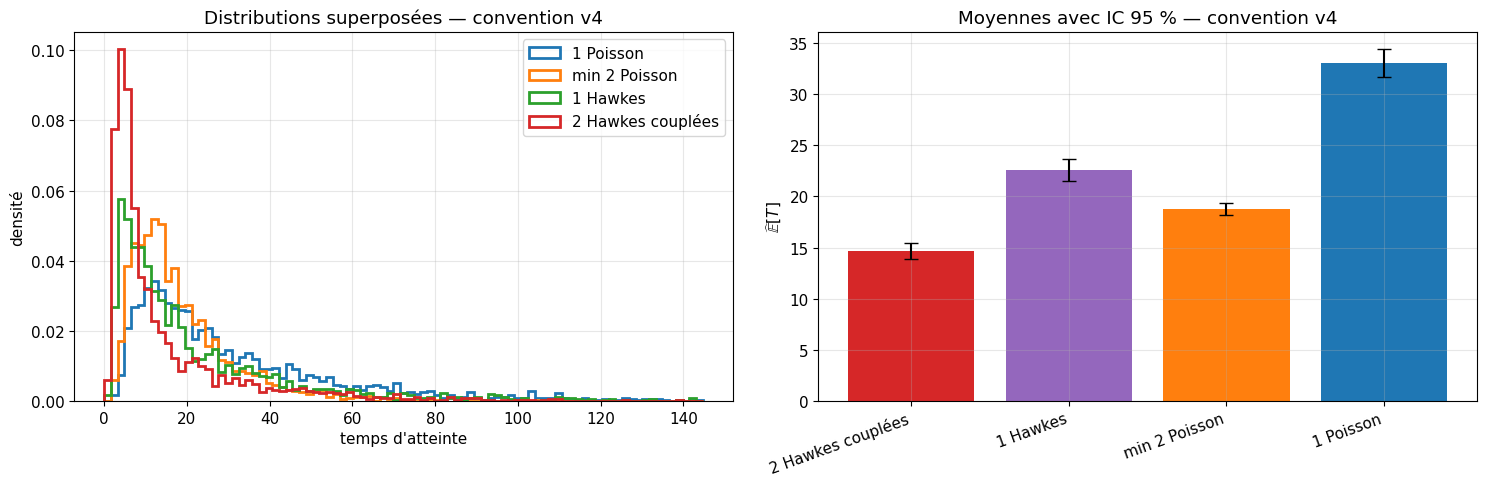

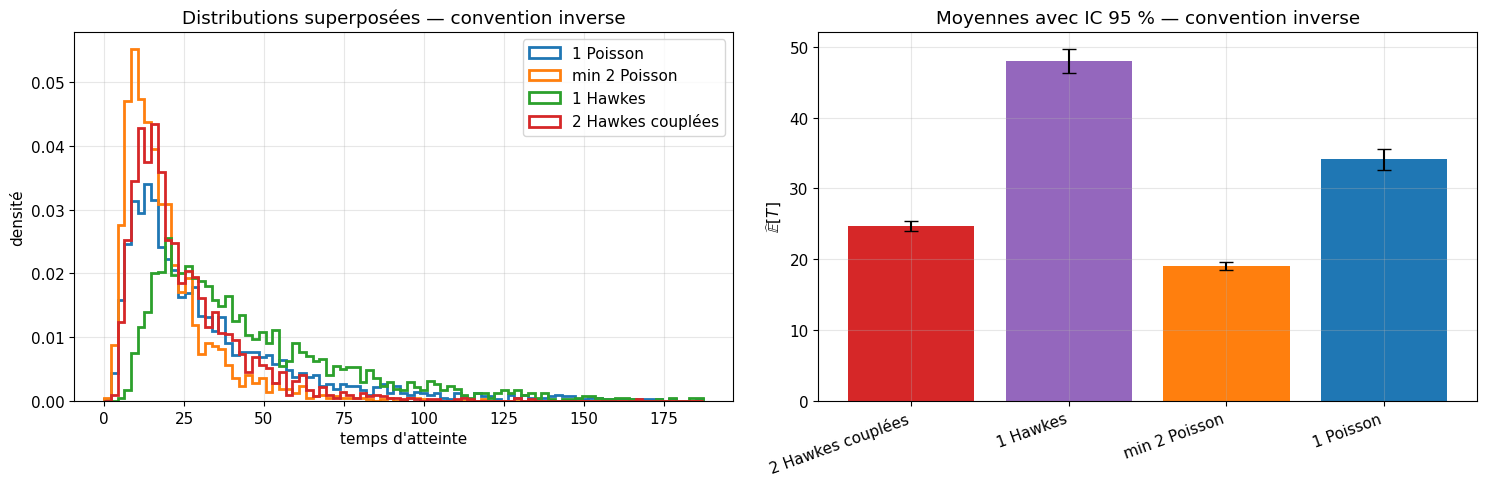

In [18]:
ordre_attendu = ["2 Hawkes couplées", "1 Hawkes", "min 2 Poisson", "1 Poisson"]

def verifier_ordre(table, convention):
    sous_table = table[table["convention"] == convention].set_index("modèle")
    moyennes = sous_table.loc[ordre_attendu, "E[T]"].values
    ok = bool(np.all(np.diff(moyennes) > 0))
    return ok, moyennes

for convention in ["v4", "inverse"]:
    ok, moyennes = verifier_ordre(table_comparaison, convention)
    print(f"Convention {convention} : ordre attendu vérifié ? {ok}")
    for nom, val in zip(ordre_attendu, moyennes):
        print(f"  {nom:20s} : {val:.4f}")

donnees_a_tracer = {"v4": donnees_v4, "inverse": donnees_inverse}

for convention, donnees in donnees_a_tracer.items():
    valeurs = np.concatenate(list(donnees.values()))
    bins = np.linspace(0, np.quantile(valeurs, 0.995), 90)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for nom in ordre_attendu[::-1]:
        axes[0].hist(donnees[nom], bins=bins, density=True, histtype="step", linewidth=2, label=nom)
    axes[0].set_xlabel("temps d'atteinte")
    axes[0].set_ylabel("densité")
    axes[0].set_title(f"Distributions superposées — convention {convention}")
    axes[0].legend()

    table_conv = table_comparaison[table_comparaison["convention"] == convention].set_index("modèle").loc[ordre_attendu]
    moy = table_conv["E[T]"].values
    err = np.vstack([
        moy - table_conv["IC 95% bas"].values,
        table_conv["IC 95% haut"].values - moy,
    ])
    axes[1].bar(range(len(ordre_attendu)), moy, yerr=err, capsize=5, color=["tab:red", "tab:purple", "tab:orange", "tab:blue"])
    axes[1].set_xticks(range(len(ordre_attendu)))
    axes[1].set_xticklabels(ordre_attendu, rotation=20, ha="right")
    axes[1].set_ylabel(r"$\widehat{\mathbb{E}}[T]$")
    axes[1].set_title(f"Moyennes avec IC 95 % — convention {convention}")

    plt.tight_layout()
    plt.show()


**Discussion obligatoire.** Les deux conventions n'ont pas la même
interprétation physique.

Avec la convention **v4**, un ajout rend la file plus persistante : il réduit
temporairement le taux de retrait. Un retrait, au contraire, signale une
consommation en cours et augmente temporairement le taux de retrait. Cette
convention met l'accent sur l'inertie puis sur l'emballement de la déplétion.

Avec la convention **inverse**, un ajout excite les retraits futurs. Cela
modélise une réaction plus agressive des participants lorsque la file grossit,
et peut conduire à des temps d'atteinte plus courts pour la file Hawkes seule.

Le tableau et les figures précédents indiquent quelle convention reproduit
l'ordre attendu par l'énoncé. Si l'ordre n'est pas vérifié sous v4 mais l'est
sous la convention inverse, cela confirme que les figures historiques du sujet
ont probablement été produites avec la convention initiale. Si v4 vérifie
l'ordre, on retient la version corrigée comme cohérente avec l'équation v4 et
avec l'interprétation inertie puis auto-excitation des retraits.
